In [82]:
import numpy as np
import control as ct
from matplotlib import pyplot as plt

from letalker.constants import vocaltract_areas, rho_air, c
from letalker.constants import vocaltract_resolution as length
from letalker.vt_components import segments, cascade, endpoints, junctions

area = 4.0
fs = 44100
sample_kws = {"method": "bilinear"}

series = sum(
    [
        z(area, 1)
        for z in (
            segments.DefaultInertance(),
            segments.DefaultViscousLossTF(resistive_only=False),
            segments.DefaultLaminarResistance(),
        )
    ]
)

shunt = sum(
    [
        1 / z(area, 1)
        for z in (
            segments.DefaultCompliance(),
            segments.DefaultYieldingWall(),
            segments.DefaultHeatLossGain(),
        )
    ]
)

print(series)
print(shunt)


<TransferFunction>: sys[408]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.0002868 s + 0.01173
  ---------------------
            1
<TransferFunction>: sys[421]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  1.302e-10 s^3 + 1.019e-07 s^2 + 0.0002247 s + 0.0002179
  -------------------------------------------------------
               4.545e-05 s^2 + 0.03212 s + 1


<TransferFunction>: sys[422]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   1.304e-08 s^3 + 9.746e-06 s^2 + 0.0006636 s + 0.01173
  -------------------------------------------------------
  1.302e-10 s^3 + 1.019e-07 s^2 + 0.0002247 s + 0.0002179


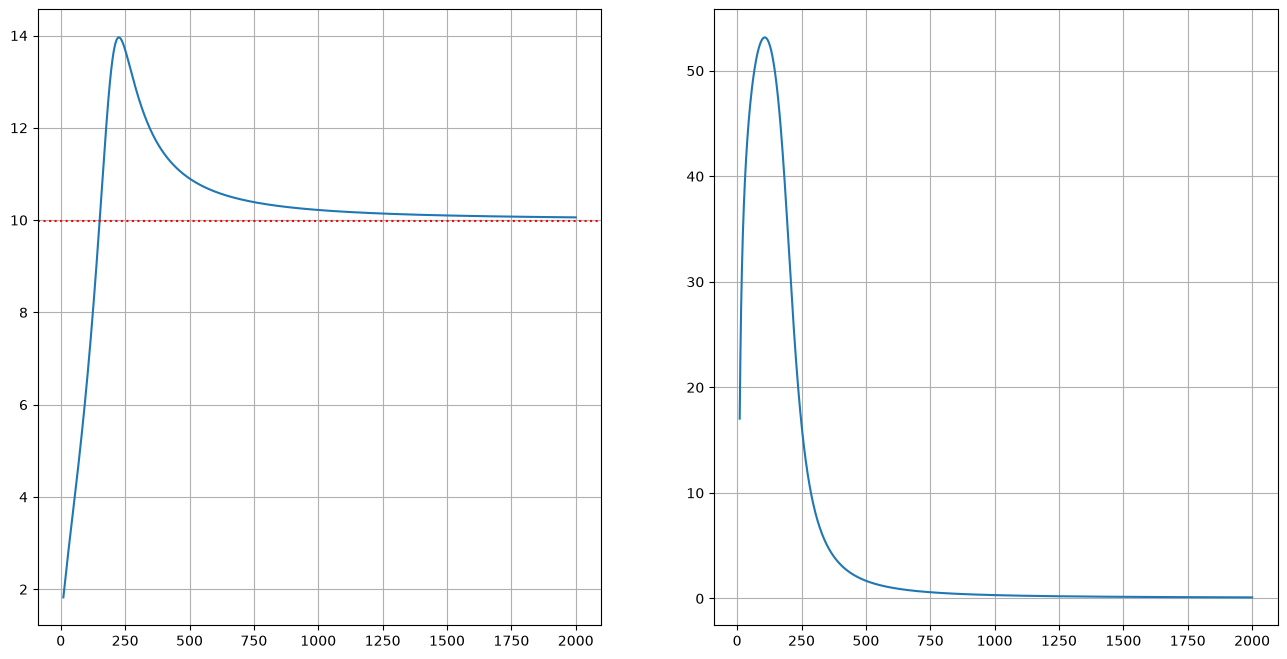

In [83]:
from math import pi
import numpy as np
from matplotlib import pyplot as plt

Z0sq = series / shunt
print(Z0sq)
resp = ct.frequency_response(Z0sq, omega_limits=[2 * pi * 10, 2 * pi * 2000])[0, 0]

f = resp.frequency / (2 * pi)
Z0 = np.sqrt(resp.complex)

fig,axes = plt.subplots(1,2,figsize=(16,8))
axes[0].plot(f, np.abs(Z0))
axes[0].axhline(rho_air * c / area, c="r", ls=":")
axes[0].grid()
axes[1].plot(f, np.angle(Z0)*180/pi)
axes[1].grid()


<TransferFunction>: sys[424]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  3.734e-14 s^4 + 3.076e-11 s^3 + 6.565e-08 s^2 + 2.698e-06 s + 2.556e-06
  -----------------------------------------------------------------------
                       4.545e-05 s^2 + 0.03212 s + 1
0.000285


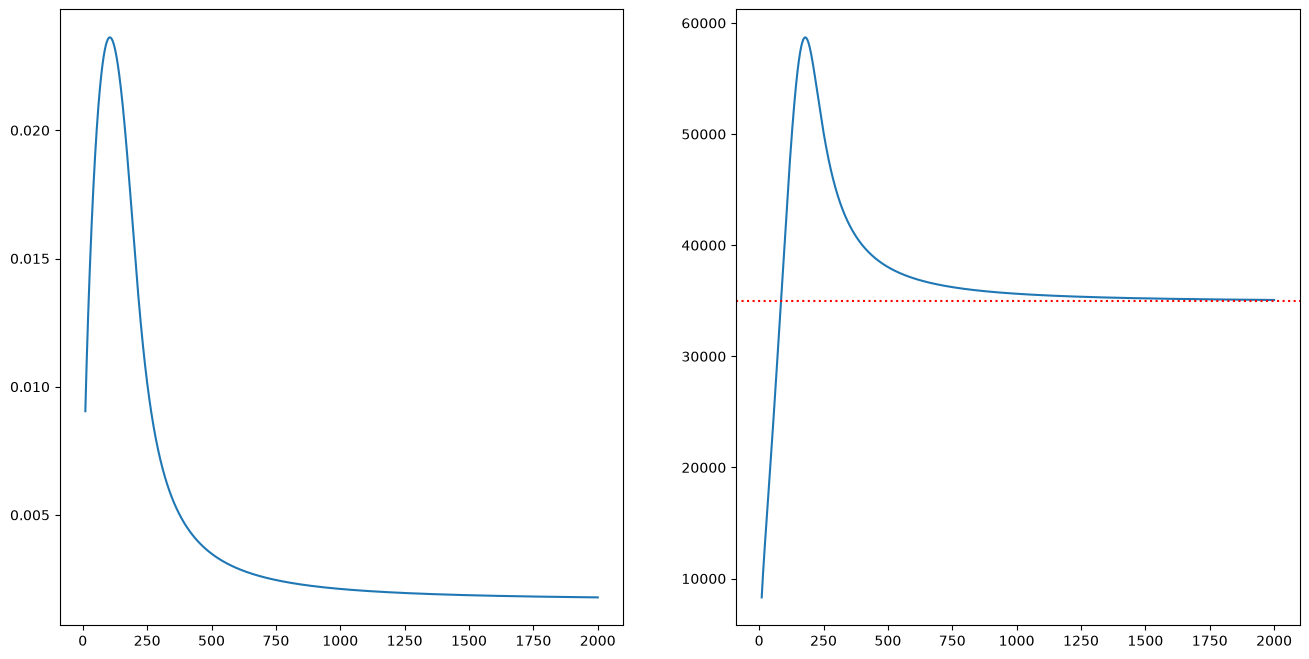

In [84]:
gamma = series * shunt
print(gamma)
resp = ct.frequency_response(gamma, omega_limits=[2 * pi * 10, 2 * pi * 2000])[0, 0]

f = resp.frequency / (2 * pi)
G = np.sqrt(resp.complex)

fig,axes = plt.subplots(1,2,figsize=(16,8))
axes[0].plot(f, np.real(G))
axes[1].plot(f, resp.frequency/np.imag(G))
axes[1].axhline(c,c='r',ls=':')
print(rho_air/area)